<a href="https://colab.research.google.com/github/jadenevesmoreira-rgb/jadenevesmoreira-rgb/blob/main/Projeto_de_parceria_Semantix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Identificação de Perfis Sociodemográficos entre Candidatos a Vereador nas Eleições Municipais Brasileiras de 2024 por meio de Técnicas de Clusterização**

A representação política no Brasil é frequentemente associada a um perfil bastante específico. Diversos estudos apontam que os ocupantes de cargos eletivos são, em sua maioria, homens, mais velhos, casados, brancos e com elevados níveis de escolaridade. No entanto, essa constatação levanta uma questão importante para a compreensão dos processos de recrutamento político e representação democrática: esse perfil caracteriza o conjunto de indivíduos que disputam as eleições ou apenas aqueles que conseguem ser eleitos?

Embora exista uma vasta literatura dedicada à análise do perfil dos representantes políticos, ainda são relativamente escassos os estudos que investigam as características sociodemográficas do universo mais amplo de candidatos. Nesse sentido, compreender quem são os indivíduos que se colocam à disposição do eleitorado constitui um passo fundamental para avaliar o grau de diversidade presente na competição política brasileira e para identificar possíveis barreiras que afetam a transformação de candidaturas em mandatos.

Com o objetivo de contribuir para esse debate, este projeto busca identificar e analisar perfis sociodemográficos entre os candidatos ao cargo de vereador nas eleições municipais de 2024. A proposta consiste em investigar se existem grupos distintos de candidatos que compartilham características semelhantes relacionadas a gênero, idade, cor/raça, grau de instrução e estado civil, permitindo compreender de forma mais aprofundada a composição social daqueles que buscaram ingressar nos legislativos municipais brasileiros.

Para isso, serão utilizados dados disponibilizados pelo Tribunal Superior Eleitoral por meio de seu portal de dados abertos. A base de dados contempla todos os candidatos registrados para as eleições municipais de 2024, abrangendo centenas de milhares de observações distribuídas pelos municípios do país. Entre as informações disponíveis, destacam-se variáveis sociodemográficas que possibilitam a construção de perfis detalhados dos candidatos.

Do ponto de vista metodológico, a análise será realizada por meio de técnicas de aprendizado de máquina não supervisionado, com destaque para algoritmos de clusterização. Diferentemente dos modelos supervisionados, que têm como objetivo prever um resultado conhecido, os métodos de clustering procuram identificar agrupamentos naturais existentes nos dados, reunindo observações que apresentam características semelhantes e separando aquelas que possuem perfis distintos.

A utilização dessa abordagem permite que os próprios dados revelem padrões estruturais presentes entre os candidatos, sem a necessidade de impor categorias previamente definidas pelo pesquisador. Dessa forma, espera-se identificar diferentes perfis sociodemográficos que coexistem no universo das candidaturas, evidenciando semelhanças e diferenças entre grupos de indivíduos que participaram da disputa eleitoral municipal.

Ao final, a pesquisa pretende oferecer uma visão mais abrangente sobre quem são os candidatos a vereador no Brasil contemporâneo, contribuindo para discussões relacionadas à representação política, recrutamento partidário e diversidade nos espaços institucionais de poder. Além disso, o projeto busca demonstrar o potencial da aplicação de técnicas de ciência de dados e aprendizado de máquina em pesquisas da área de ciência política, explorando novas possibilidades metodológicas para a análise de fenômenos eleitorais em larga escala.

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
!pip install kmodes
from kmodes.kprototypes import KPrototypes
import numpy as np

In [2]:
# Carregar a base de dados
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/candidatos_2024_BRASIL.csv',
    sep=';',
    encoding='latin1'
)

df.head()

Mounted at /content/drive


,ANO_ELEICAO,SG_UF,NM_UE,DS_CARGO,NM_URNA_CANDIDATO,DT_NASCIMENTO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA
0,2024,MG,FORTUNA DE MINAS,VEREADOR,VANILA,NaN,-4,NÇO DIVULGµVEL,-4,NÇO DIVULGµVEL,-4,NÇO DIVULGµVEL,-4,NÇO DIVULGµVEL
1,2024,SC,PINHEIRO PRETO,VEREADOR,ADAIR HACK,04/06/1965,2,MASCULINO,4,ENSINO FUNDAMENTAL COMPLETO,7,SEPARADO(A) JUDICIALMENTE,1,BRANCA
2,2024,ES,DIVINO DE SÇO LOURENO,VEREADOR,DAVID DO BIGODE,24/01/2002,2,MASCULINO,6,ENSINO MDIO COMPLETO,3,CASADO(A),1,BRANCA
3,2024,PA,XINGUARA,VEREADOR,ANA CLAUDIA,23/08/1974,4,FEMININO,6,ENSINO MDIO COMPLETO,3,CASADO(A),1,BRANCA
4,2024,CE,UMIRIM,VEREADOR,CIÒ BRAGA,24/08/1986,2,MASCULINO,3,ENSINO FUNDAMENTAL INCOMPLETO,9,DIVORCIADO(A),1,BRANCA


# Análise Exploratória

In [ ]:
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432002 entries, 0 to 432001
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ANO_ELEICAO        432002 non-null  int64 
 1   SG_UF              432002 non-null  object
 2   NM_UE              432002 non-null  object
 3   DS_CARGO           432002 non-null  object
 4   NM_URNA_CANDIDATO  432001 non-null  object
 5   DT_NASCIMENTO      431962 non-null  object
 6   CD_GENERO          432002 non-null  int64 
 7   DS_GENERO          432002 non-null  object
 8   CD_GRAU_INSTRUCAO  432002 non-null  int64 
 9   DS_GRAU_INSTRUCAO  432002 non-null  object
 10  CD_ESTADO_CIVIL    432002 non-null  int64 
 11  DS_ESTADO_CIVIL    432002 non-null  object
 12  CD_COR_RACA        432002 non-null  int64 
 13  DS_COR_RACA        432002 non-null  object
dtypes: int64(5), object(9)
memory usage: 46.1+ MB


,0
ANO_ELEICAO,0
SG_UF,0
NM_UE,0
DS_CARGO,0
NM_URNA_CANDIDATO,1
DT_NASCIMENTO,40
CD_GENERO,0
DS_GENERO,0
CD_GRAU_INSTRUCAO,0
DS_GRAU_INSTRUCAO,0


In [ ]:
for col in [
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA'
]:
    print(f'\n{col}')
    print(df[col].value_counts())


DS_GENERO
DS_GENERO
MASCULINO         279016
FEMININO          152946
NÇO DIVULGµVEL        40
Name: count, dtype: int64

DS_GRAU_INSTRUCAO
DS_GRAU_INSTRUCAO
ENSINO MDIO COMPLETO            172040
SUPERIOR COMPLETO                114625
ENSINO FUNDAMENTAL COMPLETO       49052
ENSINO FUNDAMENTAL INCOMPLETO     46584
ENSINO MDIO INCOMPLETO           20307
SUPERIOR INCOMPLETO               19686
LÒ E ESCREVE                       9655
NÇO DIVULGµVEL                       40
ANALFABETO                           13
Name: count, dtype: int64

DS_ESTADO_CIVIL
DS_ESTADO_CIVIL
CASADO(A)                    213366
SOLTEIRO(A)                  165246
DIVORCIADO(A)                 41077
VIéVO(A)                       8800
SEPARADO(A) JUDICIALMENTE      3473
NÇO DIVULGµVEL                   40
Name: count, dtype: int64

DS_COR_RACA
DS_COR_RACA
BRANCA            197776
PARDA             176621
PRETA              50769
NÇO INFORMADO       2658
INDÖGENA            2461
AMARELA             1677
NÇO D

In [3]:
# Correção das categorias com problemas de encoding
colunas_texto = [
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA'
]

for col in colunas_texto:
    df[col] = df[col].replace(
        'NÇO DIVULGµVEL',
        'Outro'
    )

In [4]:
df['DS_GRAU_INSTRUCAO'] = df['DS_GRAU_INSTRUCAO'].replace({
    'LÒ E ESCREVE': 'LÊ E ESCREVE',
    'ENSINO M\x90DIO COMPLETO': 'ENSINO MÉDIO COMPLETO',
    'ENSINO M\x90DIO INCOMPLETO': 'ENSINO MÉDIO INCOMPLETO'
})

df['DS_ESTADO_CIVIL'] = df['DS_ESTADO_CIVIL'].replace({
    'VIéVO(A)': 'VIÚVO(A)'
})

df['DS_COR_RACA'] = df['DS_COR_RACA'].replace({
    'NÇO INFORMADO': 'NÃO INFORMADO',
    'INDÖGENA': 'INDÍGENA'
})

In [ ]:
# Verificar as substituições
for col in [
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA'
]:
    print(f'\n{col}')
    print(sorted(df[col].unique()))


DS_GENERO
['FEMININO', 'MASCULINO', 'Outro']

DS_GRAU_INSTRUCAO
['ANALFABETO', 'ENSINO FUNDAMENTAL COMPLETO', 'ENSINO FUNDAMENTAL INCOMPLETO', 'ENSINO MÉDIO COMPLETO', 'ENSINO MÉDIO INCOMPLETO', 'LÊ E ESCREVE', 'Outro', 'SUPERIOR COMPLETO', 'SUPERIOR INCOMPLETO']

DS_ESTADO_CIVIL
['CASADO(A)', 'DIVORCIADO(A)', 'Outro', 'SEPARADO(A) JUDICIALMENTE', 'SOLTEIRO(A)', 'VIÚVO(A)']

DS_COR_RACA
['AMARELA', 'BRANCA', 'INDÍGENA', 'NÃO INFORMADO', 'Outro', 'PARDA', 'PRETA']


DS_COR_RACA
BRANCA           197776
PARDA            176621
PRETA             50769
NÃO INFORMADO      2658
INDÍGENA           2461
AMARELA            1677
Outro                40
Name: count, dtype: int64


<Axes: title={'center': 'Distribuição dos candidatos por cor/raça'}, xlabel='DS_COR_RACA'>

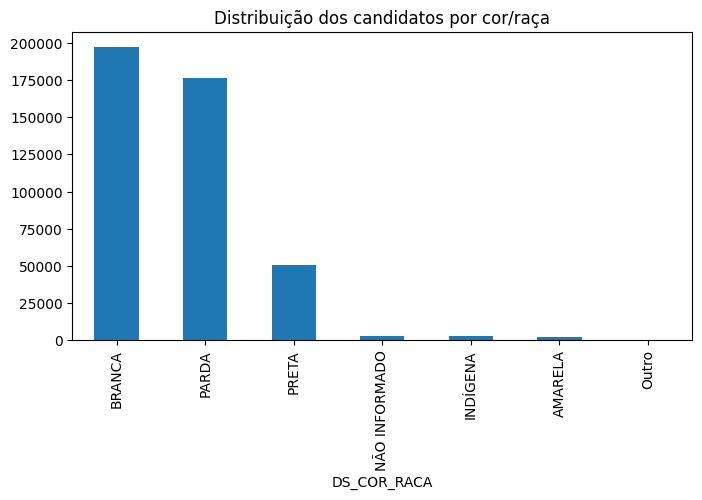

In [ ]:
# Distribuição por Cor/Raça
raca = df['DS_COR_RACA'].value_counts()

print(raca)

raca.plot(
    kind='bar',
    figsize=(8,4),
    title='Distribuição dos candidatos por cor/raça'
)

In [ ]:
# Percentuais da distribuição
raca_pct = (
    df['DS_COR_RACA']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(raca_pct)

DS_COR_RACA
BRANCA           45.78
PARDA            40.88
PRETA            11.75
NÃO INFORMADO     0.62
INDÍGENA          0.57
AMARELA           0.39
Outro             0.01
Name: proportion, dtype: float64


DS_GENERO
MASCULINO    279016
FEMININO     152946
Outro            40
Name: count, dtype: int64


<Axes: title={'center': 'Distribuição dos candidatos por gênero'}, xlabel='DS_GENERO'>

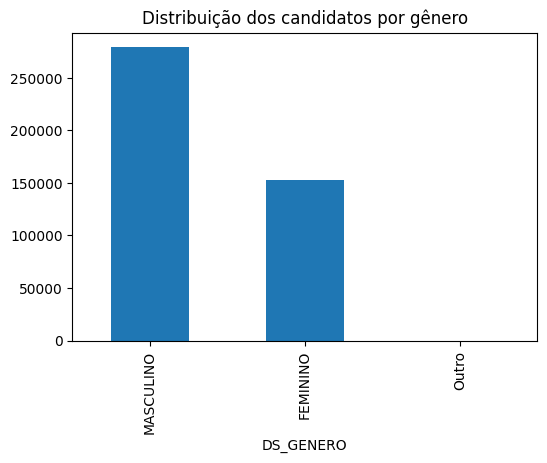

In [ ]:
# Distribuição por Gênero
genero = df['DS_GENERO'].value_counts()

print(genero)

genero.plot(
    kind='bar',
    figsize=(6,4),
    title='Distribuição dos candidatos por gênero'
)

In [ ]:
# Percentuais da distribuição
genero_pct = (
    df['DS_GENERO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(genero_pct)

DS_GENERO
MASCULINO    64.59
FEMININO     35.40
Outro         0.01
Name: proportion, dtype: float64


DS_GRAU_INSTRUCAO
ENSINO MÉDIO COMPLETO            172040
SUPERIOR COMPLETO                114625
ENSINO FUNDAMENTAL COMPLETO       49052
ENSINO FUNDAMENTAL INCOMPLETO     46584
ENSINO MÉDIO INCOMPLETO           20307
SUPERIOR INCOMPLETO               19686
LÊ E ESCREVE                       9655
Outro                                40
ANALFABETO                           13
Name: count, dtype: int64


<Axes: title={'center': 'Distribuição dos candidatos por escolaridade'}, xlabel='DS_GRAU_INSTRUCAO'>

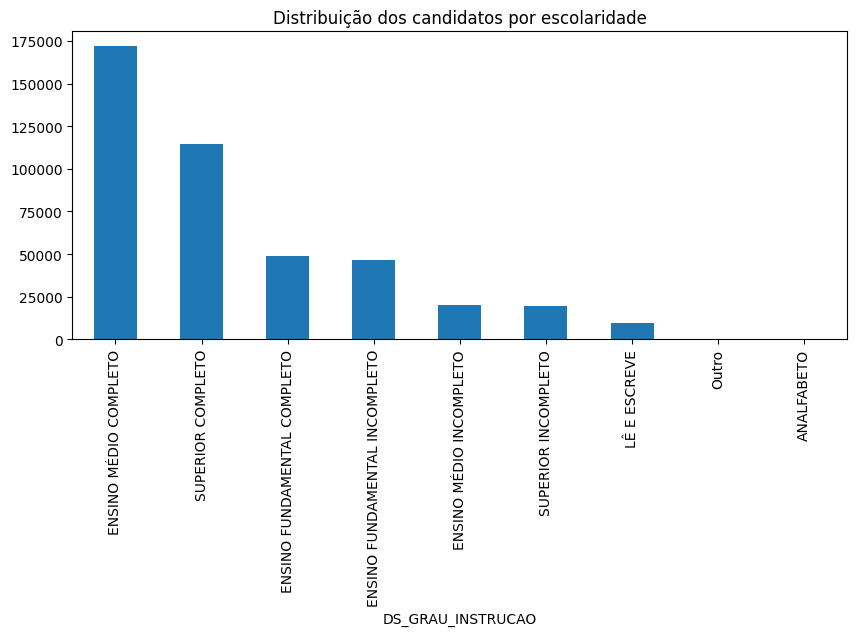

In [ ]:
# Distribuição por Escolaridade
escolaridade = df['DS_GRAU_INSTRUCAO'].value_counts()

print(escolaridade)

escolaridade.plot(
    kind='bar',
    figsize=(10,4),
    title='Distribuição dos candidatos por escolaridade'
)

In [ ]:
# Percentuais da distribuição
escolaridade_pct = (
    df['DS_GRAU_INSTRUCAO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(escolaridade_pct)

DS_GRAU_INSTRUCAO
ENSINO MÉDIO COMPLETO            39.82
SUPERIOR COMPLETO                26.53
ENSINO FUNDAMENTAL COMPLETO      11.35
ENSINO FUNDAMENTAL INCOMPLETO    10.78
ENSINO MÉDIO INCOMPLETO           4.70
SUPERIOR INCOMPLETO               4.56
LÊ E ESCREVE                      2.23
Outro                             0.01
ANALFABETO                        0.00
Name: proportion, dtype: float64


DS_ESTADO_CIVIL
CASADO(A)                    213366
SOLTEIRO(A)                  165246
DIVORCIADO(A)                 41077
VIÚVO(A)                       8800
SEPARADO(A) JUDICIALMENTE      3473
Outro                            40
Name: count, dtype: int64


<Axes: title={'center': 'Distribuição dos candidatos por estado civil'}, xlabel='DS_ESTADO_CIVIL'>

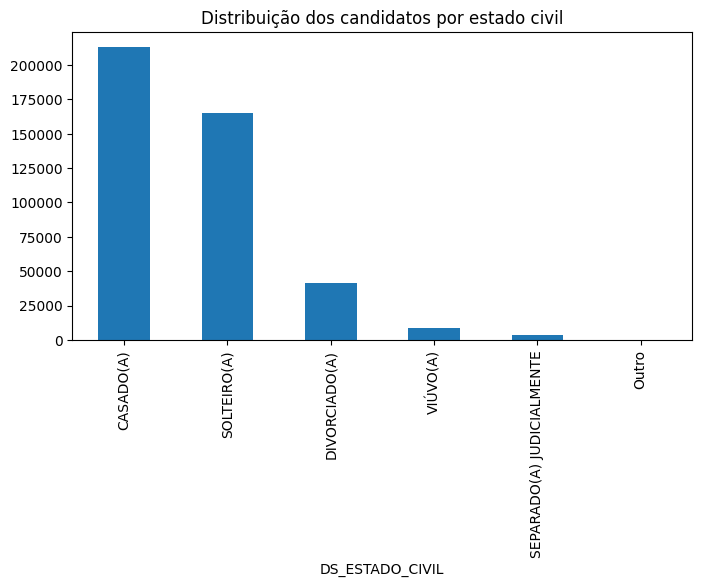

In [ ]:
# Distribuição por Estado Civil
estado_civil = df['DS_ESTADO_CIVIL'].value_counts()

print(estado_civil)

estado_civil.plot(
    kind='bar',
    figsize=(8,4),
    title='Distribuição dos candidatos por estado civil'
)

In [ ]:
# Percentual da distribuição
estado_pct = (
    df['DS_ESTADO_CIVIL']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(estado_pct)

DS_ESTADO_CIVIL
CASADO(A)                    49.39
SOLTEIRO(A)                  38.25
DIVORCIADO(A)                 9.51
VIÚVO(A)                      2.04
SEPARADO(A) JUDICIALMENTE     0.80
Outro                         0.01
Name: proportion, dtype: float64


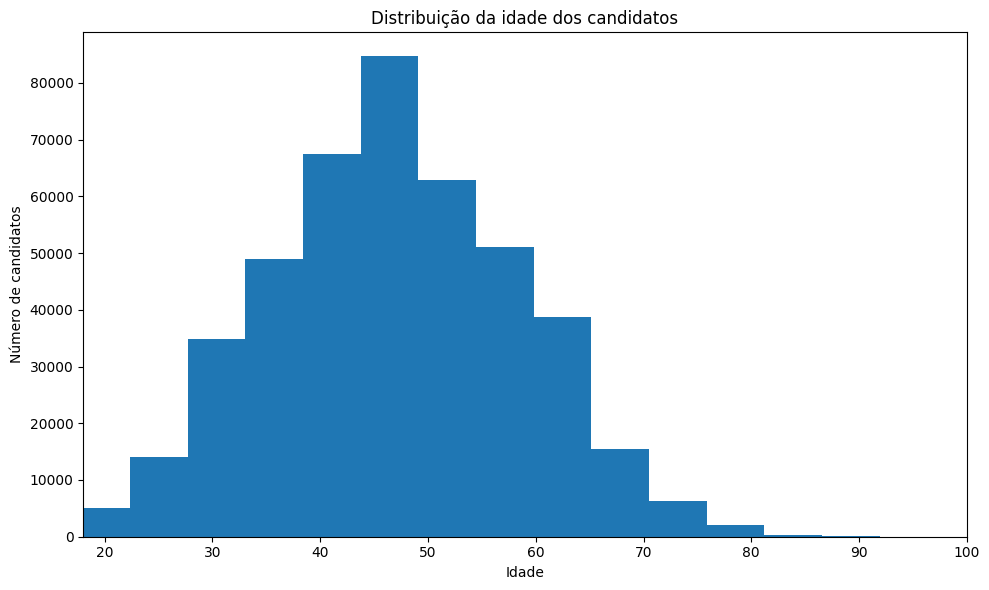

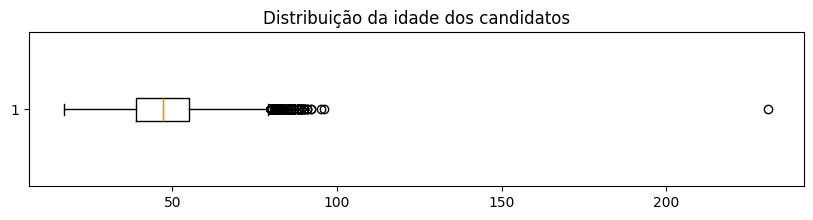

In [5]:
# Distribuição por Idade
df['DT_NASCIMENTO'] = pd.to_datetime(
    df['DT_NASCIMENTO'],
    format='%d/%m/%Y',
    errors='coerce'
)

df['IDADE'] = 2024 - df['DT_NASCIMENTO'].dt.year

plt.figure(figsize=(10,6))

plt.hist(
    df['IDADE'],
    bins=40
)

plt.xlim(18, 100)

plt.title('Distribuição da idade dos candidatos')
plt.xlabel('Idade')
plt.ylabel('Número de candidatos')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,2))

plt.boxplot(
    df['IDADE'].dropna(),
    vert=False
)

plt.title('Distribuição da idade dos candidatos')

plt.show()

In [ ]:
# Verificar outlier na variável Idade
print(df['IDADE'].max())

df[df['IDADE'] == df['IDADE'].max()][
    ['NM_URNA_CANDIDATO',
     'DT_NASCIMENTO',
     'IDADE',
     'SG_UF']
]

231.0


,NM_URNA_CANDIDATO,DT_NASCIMENTO,IDADE,SG_UF
133762,LEI BERNARDO,1793-03-06,231.0,MG


In [ ]:
df[['IDADE', 'DT_NASCIMENTO']].sort_values(
    by='IDADE',
    ascending=False
).head(20)

,IDADE,DT_NASCIMENTO
133762,231.0,1793-03-06
270856,96.0,1928-07-15
90482,95.0,1929-11-15
265170,92.0,1932-04-10
194784,92.0,1932-07-11
204459,91.0,1933-10-15
80214,91.0,1933-06-15
286766,91.0,1933-07-09
429737,90.0,1934-09-29
324279,90.0,1934-04-20


In [6]:
# Tratamento do outlier identificado
df = df[df['IDADE'] <= 100]

In [7]:
print(df['IDADE'].min())
print(df['IDADE'].max())

17.0
96.0


In [ ]:
# Estatísticas de Idade após tratamento do outlier
df['IDADE'].describe()

,IDADE
count,431958.000000
mean,46.972379
std,11.492938
min,17.000000
25%,39.000000
50%,47.000000
75%,55.000000
max,96.000000


In [ ]:
df['IDADE'].median()

47.0

A identificação de outliers foi realizada por meio de estatísticas descritivas e inspeção gráfica da distribuição etária dos candidatos. Foi detectado um único caso com idade de 231 anos, valor incompatível com os limites biológicos da espécie humana e, portanto, caracterizado como erro de registro. Seguindo recomendações da literatura de mineração de dados e aprendizado de máquina, observações manifestamente inválidas foram removidas antes da etapa de modelagem, uma vez que podem influenciar medidas de tendência central, dispersão e algoritmos baseados em distância euclidiana, como o K-Means.

# Preparação dos Dados para Clusterização

In [8]:
# Seleção das variáveis
df_cluster = df[
    [
        'DS_GENERO',
        'DS_COR_RACA',
        'DS_GRAU_INSTRUCAO',
        'DS_ESTADO_CIVIL',
        'IDADE'
    ]
].copy()

df_cluster.head()

,DS_GENERO,DS_COR_RACA,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL,IDADE
1,MASCULINO,BRANCA,ENSINO FUNDAMENTAL COMPLETO,SEPARADO(A) JUDICIALMENTE,59.0
2,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A),22.0
3,FEMININO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A),50.0
4,MASCULINO,BRANCA,ENSINO FUNDAMENTAL INCOMPLETO,DIVORCIADO(A),38.0
5,MASCULINO,BRANCA,ENSINO FUNDAMENTAL INCOMPLETO,SOLTEIRO(A),47.0


In [9]:
# One-Hot Encoding para as variáveis categóricas
df_encoded = pd.get_dummies(
    df_cluster,
    columns=[
        'DS_GENERO',
        'DS_COR_RACA',
        'DS_GRAU_INSTRUCAO',
        'DS_ESTADO_CIVIL'
    ],
    drop_first=False
)

df_encoded.head()

,IDADE,DS_GENERO_FEMININO,DS_GENERO_MASCULINO,DS_COR_RACA_AMARELA,DS_COR_RACA_BRANCA,DS_COR_RACA_INDÍGENA,DS_COR_RACA_NÃO INFORMADO,DS_COR_RACA_PARDA,DS_COR_RACA_PRETA,DS_GRAU_INSTRUCAO_ANALFABETO,...,DS_GRAU_INSTRUCAO_ENSINO MÉDIO COMPLETO,DS_GRAU_INSTRUCAO_ENSINO MÉDIO INCOMPLETO,DS_GRAU_INSTRUCAO_LÊ E ESCREVE,DS_GRAU_INSTRUCAO_SUPERIOR COMPLETO,DS_GRAU_INSTRUCAO_SUPERIOR INCOMPLETO,DS_ESTADO_CIVIL_CASADO(A),DS_ESTADO_CIVIL_DIVORCIADO(A),DS_ESTADO_CIVIL_SEPARADO(A) JUDICIALMENTE,DS_ESTADO_CIVIL_SOLTEIRO(A),DS_ESTADO_CIVIL_VIÚVO(A)
1,59.0,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,22.0,False,True,False,True,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,50.0,True,False,False,True,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4,38.0,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
5,47.0,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
print(df_encoded.shape)

(431958, 22)


In [ ]:
# Padronização da Idade

scaler = StandardScaler()

df_encoded['IDADE'] = scaler.fit_transform(
    df_encoded[['IDADE']]
)

df_encoded['IDADE'].describe()

,IDADE
count,4.319580e+05
mean,-2.608867e-17
std,1.000001e+00
min,-2.607898e+00
25%,-6.936772e-01
50%,2.403282e-03
75%,6.984837e-01
max,4.265896e+00


In [ ]:
# Método do Cotovelo para testar diferentes números de clusters
inercia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_encoded)

    inercia.append(kmeans.inertia_)

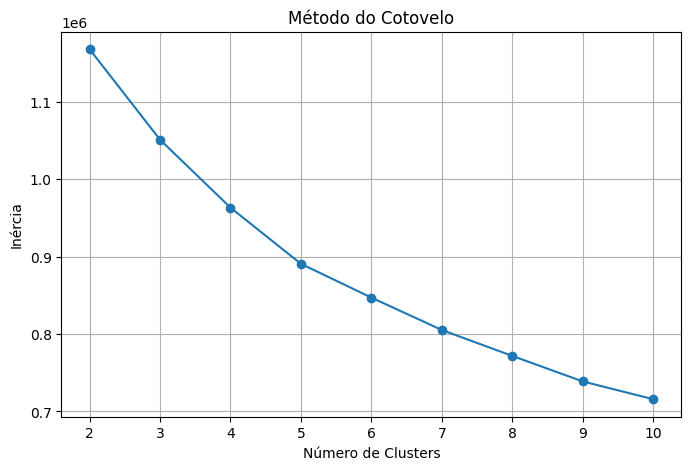

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inercia,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')

plt.grid(True)

plt.show()

In [ ]:
# Silhouette Score

silhouette_scores = []

amostra = df_encoded.sample(
    n=10000,
    random_state=42
)

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(amostra)

    score = silhouette_score(
        amostra,
        labels
    )

    silhouette_scores.append(score)

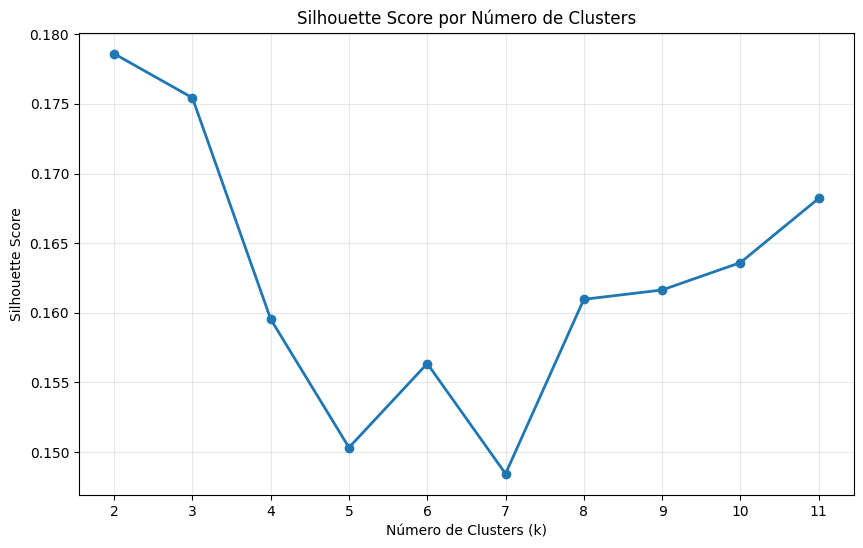

In [ ]:
k_values = range(2, 12)

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2
)

plt.title('Silhouette Score por Número de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

A determinação do número ideal de clusters foi realizada por meio da combinação de dois critérios amplamente utilizados na literatura de aprendizado de máquina não supervisionado: o Método do Cotovelo (Elbow Method) e o Silhouette Score.

O Método do Cotovelo indicou uma redução expressiva da inércia à medida que o número de clusters aumentava até aproximadamente cinco grupos. A partir desse ponto, observou-se uma diminuição gradual dos ganhos obtidos com a adição de novos clusters, sugerindo que valores superiores a cinco produziam melhorias marginais na capacidade de agrupamento dos dados.

Complementarmente, o Silhouette Score apresentou seus maiores valores para números reduzidos de clusters, especialmente para k = 2 e k = 3. Entretanto, embora esses resultados indiquem maior separação entre os grupos, soluções com poucos clusters tendem a gerar perfis excessivamente amplos e pouco informativos para os objetivos substantivos da pesquisa.

Considerando conjuntamente os resultados dos dois indicadores e o propósito de identificar diferentes perfis sociodemográficos entre os candidatos a vereador, optou-se pela utilização de k = 5. Essa escolha representa um equilíbrio entre qualidade estatística dos agrupamentos e capacidade interpretativa, permitindo a identificação de grupos suficientemente distintos sem fragmentar excessivamente a população analisada.

# Modelagem (K-Means)

In [34]:
# Construção do modelo K-Means
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df_cluster['CLUSTER_KMEANS'] = kmeans_final.fit_predict(
    df_encoded
)

In [35]:
# Verificar o tamanho dos grupos
df_cluster['CLUSTER_KMEANS'].value_counts()

,count
CLUSTER_KMEANS,
2,138498
0,109122
1,97648
4,46508
3,40182


In [ ]:
(
    df_cluster['CLUSTER_KMEANS']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
CLUSTER_KMEANS,
2,23.01
0,22.19
3,19.40
4,18.02
1,17.38


In [ ]:
# 1. Idade média por cluster
df_cluster.groupby(
    'CLUSTER_KMEANS'
)['IDADE'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

,mean,median,min,max
CLUSTER_KMEANS,,,,
0,42.83,44.0,19.0,53.0
1,55.14,54.0,43.0,92.0
2,59.78,59.0,48.0,96.0
3,38.45,39.0,17.0,54.0
4,37.02,38.0,17.0,50.0


In [ ]:
# 2. Gênero predominante por cluster
pd.crosstab(
    df_cluster['CLUSTER_KMEANS'],
    df_cluster['DS_GENERO'],
    normalize='index'
).mul(100).round(2)

DS_GENERO,FEMININO,MASCULINO
CLUSTER_KMEANS,,
0,0.00,100.00
1,100.00,0.00
2,0.03,99.97
3,0.00,100.00
4,100.00,0.00


In [ ]:
# 3. Cor/Raça predominante por cluster
pd.crosstab(
    df_cluster['CLUSTER_KMEANS'],
    df_cluster['DS_COR_RACA'],
    normalize='index'
).mul(100).round(2)

DS_COR_RACA,AMARELA,BRANCA,INDÍGENA,NÃO INFORMADO,PARDA,PRETA
CLUSTER_KMEANS,,,,,,
0,0.41,41.38,0.46,0.54,45.68,11.52
1,0.38,54.05,0.41,0.59,32.55,12.02
2,0.34,55.71,0.30,0.62,33.20,9.82
3,0.36,38.05,0.95,0.71,46.78,13.15
4,0.46,38.90,0.79,0.62,46.49,12.74


In [ ]:
# 4. Escolaridade predominante por cluster
pd.crosstab(
    df_cluster['CLUSTER_KMEANS'],
    df_cluster['DS_GRAU_INSTRUCAO'],
    normalize='index'
).mul(100).round(2)

DS_GRAU_INSTRUCAO,ANALFABETO,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
CLUSTER_KMEANS,,,,,,,,
0,0.00,10.03,7.99,44.23,4.66,1.54,27.23,4.33
1,0.00,10.12,10.46,31.81,3.57,2.41,38.08,3.55
2,0.00,17.50,19.07,32.07,4.84,3.67,20.25,2.61
3,0.01,10.12,9.39,45.44,5.57,1.86,21.68,5.93
4,0.00,7.66,5.47,46.01,4.72,1.50,27.80,6.83


In [ ]:
# 5. Estado civil predominante por cluster
pd.crosstab(
    df_cluster['CLUSTER_KMEANS'],
    df_cluster['DS_ESTADO_CIVIL'],
    normalize='index'
).mul(100).round(2)

DS_ESTADO_CIVIL,CASADO(A),DIVORCIADO(A),SEPARADO(A) JUDICIALMENTE,SOLTEIRO(A),VIÚVO(A)
CLUSTER_KMEANS,,,,,
0,91.01,8.07,0.51,0.00,0.42
1,50.49,16.58,1.38,24.56,6.99
2,64.17,13.89,1.46,18.03,2.45
3,0.00,1.54,0.13,98.27,0.06
4,31.40,7.46,0.50,59.77,0.86


In [ ]:
# 6. Perfil modal de cada cluster
perfil_clusters = df_cluster.groupby(
    'CLUSTER_KMEANS'
).agg({
    'IDADE':'mean',
    'DS_GENERO': lambda x: x.mode()[0],
    'DS_COR_RACA': lambda x: x.mode()[0],
    'DS_GRAU_INSTRUCAO': lambda x: x.mode()[0],
    'DS_ESTADO_CIVIL': lambda x: x.mode()[0]
})

perfil_clusters.round(2)

,IDADE,DS_GENERO,DS_COR_RACA,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL
CLUSTER_KMEANS,,,,,
0,42.83,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,CASADO(A)
1,55.14,FEMININO,BRANCA,SUPERIOR COMPLETO,CASADO(A)
2,59.78,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
3,38.45,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,SOLTEIRO(A)
4,37.02,FEMININO,PARDA,ENSINO MÉDIO COMPLETO,SOLTEIRO(A)


A aplicação do algoritmo K-Means revelou cinco perfis sociodemográficos distintos entre os candidatos a vereador nas eleições municipais de 2024. Os agrupamentos foram fortemente influenciados pelo gênero e pela idade dos candidatos, indicando que essas características constituem importantes dimensões de diferenciação no universo das candidaturas. Em linhas gerais, o modelo distinguiu homens e mulheres em diferentes estágios do ciclo de vida, além de identificar diferenças relacionadas à escolaridade e à cor/raça. Destaca-se especialmente a formação de um cluster composto por mulheres mais velhas, majoritariamente brancas e com elevados níveis de escolaridade, bem como um cluster formado por homens mais velhos, predominantemente brancos e casados. Também foram identificados grupos de candidatos mais jovens, caracterizados por maior presença de indivíduos pardos e solteiros.

# Modelagem (K-Prototypes)

In [10]:
# Seleção das variáveis
df_kproto = df[
    [
        'DS_GENERO',
        'DS_COR_RACA',
        'DS_GRAU_INSTRUCAO',
        'DS_ESTADO_CIVIL',
        'IDADE'
    ]
].copy()

In [11]:
# Converter para NumPy
X = df_kproto.to_numpy()

In [12]:
# Definir colunas categóricas
categorical_columns = [0, 1, 2, 3]

In [14]:
# Definir número de clusters (k)
df_kproto_sample = df_kproto.sample(
    n=10000,
    random_state=42
)

X_sample = df_kproto_sample.to_numpy()

In [15]:
costs = []

for k in range(2,11):

    kproto = KPrototypes(
        n_clusters=k,
        init='Cao',
        random_state=42
    )

    clusters = kproto.fit_predict(
        X_sample,
        categorical=categorical_columns
    )

    costs.append(kproto.cost_)

    print(f'k={k} | Cost={kproto.cost_}')

k=2 | Cost=552674.5939996921
k=3 | Cost=331917.7796364892
k=4 | Cost=242244.81376863498
k=5 | Cost=198767.6212544049
k=6 | Cost=172718.25296810866
k=7 | Cost=159524.9677654216
k=8 | Cost=148271.29950098018
k=9 | Cost=142058.6842890873
k=10 | Cost=133194.62172459904


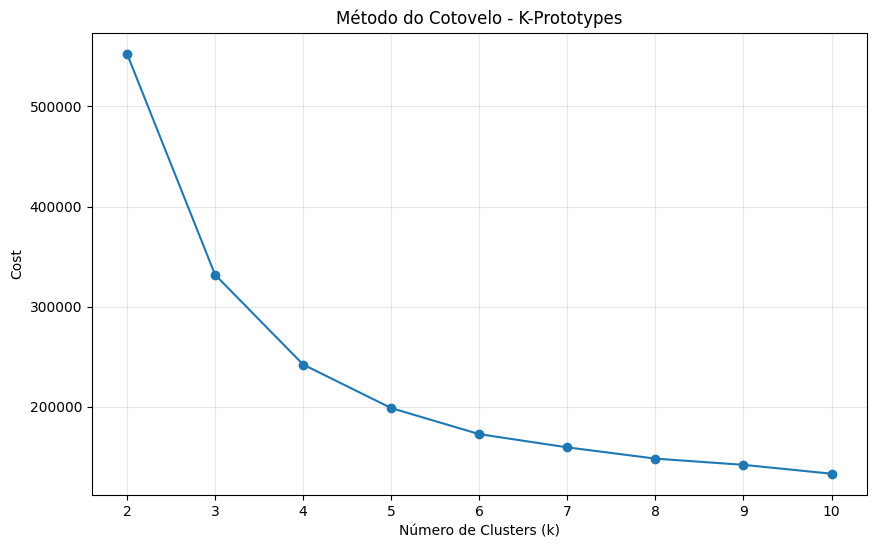

In [16]:
# Gráfico do Cotovelo
plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    costs,
    marker='o'
)

plt.title('Método do Cotovelo - K-Prototypes')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Cost')

plt.grid(alpha=0.3)

plt.show()

A aplicação do Método do Cotovelo ao algoritmo K-Prototypes indicou uma redução expressiva do custo até aproximadamente cinco clusters. A partir desse ponto, observou-se uma diminuição progressivamente menor dos ganhos associados ao aumento do número de agrupamentos. Esse resultado mostrou-se consistente com os achados obtidos pelo algoritmo K-Means, reforçando a adoção de uma solução com cinco clusters para a análise comparativa dos perfis sociodemográficos dos candidatos.

In [17]:
# Treinamento do modelo

kproto_final = KPrototypes(
    n_clusters=5,
    init='Cao',
    random_state=42
)

clusters_kproto = kproto_final.fit_predict(
    X,
    categorical=categorical_columns
)

In [21]:
df_kproto['CLUSTER_KPROTO'] = clusters_kproto

In [24]:
df_kproto['CLUSTER_KPROTO'].value_counts()

,count
CLUSTER_KPROTO,
3,115203
0,112381
1,90887
4,66544
2,46943


In [25]:
(
    df_kproto['CLUSTER_KPROTO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
CLUSTER_KPROTO,
3,26.67
0,26.02
1,21.04
4,15.41
2,10.87


In [27]:
# Perfil modal dos clusters
perfil_kproto = df_kproto.groupby(
    'CLUSTER_KPROTO'
).agg({
    'IDADE':'mean',
    'DS_GENERO': lambda x: x.mode()[0],
    'DS_COR_RACA': lambda x: x.mode()[0],
    'DS_GRAU_INSTRUCAO': lambda x: x.mode()[0],
    'DS_ESTADO_CIVIL': lambda x: x.mode()[0]
})

perfil_kproto.round(2)

,IDADE,DS_GENERO,DS_COR_RACA,DS_GRAU_INSTRUCAO,DS_ESTADO_CIVIL
CLUSTER_KPROTO,,,,,
0,39.95,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,CASADO(A)
1,56.64,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
2,66.84,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
3,48.17,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
4,29.55,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,SOLTEIRO(A)


In [29]:
# Idade média por cluster
df_kproto.groupby(
    'CLUSTER_KPROTO'
)['IDADE'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

,mean,median,min,max
CLUSTER_KPROTO,,,,
0,39.95,40.0,35.0,44.0
1,56.64,56.0,53.0,61.0
2,66.84,66.0,62.0,96.0
3,48.17,48.0,44.0,52.0
4,29.55,30.0,17.0,35.0


In [30]:
# Distribuição de gênero por cluster
pd.crosstab(
    df_kproto['CLUSTER_KPROTO'],
    df_kproto['DS_GENERO'],
    normalize='index'
).mul(100).round(2)

DS_GENERO,FEMININO,MASCULINO
CLUSTER_KPROTO,,
0,36.50,63.50
1,33.24,66.76
2,29.35,70.65
3,35.56,64.44
4,40.53,59.47


In [31]:
# Distribuição de cor/raça por cluster
pd.crosstab(
    df_kproto['CLUSTER_KPROTO'],
    df_kproto['DS_COR_RACA'],
    normalize='index'
).mul(100).round(2)

DS_COR_RACA,AMARELA,BRANCA,INDÍGENA,NÃO INFORMADO,PARDA,PRETA
CLUSTER_KPROTO,,,,,,
0,0.48,38.34,0.71,0.61,46.84,13.02
1,0.32,50.38,0.38,0.62,37.17,11.14
2,0.39,57.39,0.25,0.64,31.43,9.90
3,0.36,47.05,0.52,0.62,39.95,11.50
4,0.38,41.72,0.89,0.60,44.22,12.19


In [32]:
# Distribuição de escolaridade por cluster
pd.crosstab(
    df_kproto['CLUSTER_KPROTO'],
    df_kproto['DS_GRAU_INSTRUCAO'],
    normalize='index'
).mul(100).round(2)

DS_GRAU_INSTRUCAO,ANALFABETO,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
CLUSTER_KPROTO,,,,,,,,
0,0.01,9.05,7.49,43.40,4.86,1.49,28.59,5.11
1,0.00,14.49,14.93,35.16,4.45,2.87,25.30,2.81
2,0.00,16.02,17.76,30.39,4.27,4.72,24.35,2.50
3,0.00,11.56,11.65,38.66,4.43,2.02,27.99,3.69
4,0.00,7.32,4.27,48.85,5.55,1.26,23.78,8.97


# Conclusões

A comparação entre os algoritmos K-Means e K-Prototypes revelou diferenças importantes na estrutura dos agrupamentos identificados. O K-Means produziu clusters fortemente diferenciados por gênero e faixa etária, permitindo a identificação de perfis sociodemográficos mais distintos entre os candidatos. Em contraste, o K-Prototypes gerou agrupamentos mais heterogêneos quanto ao gênero, organizando os candidatos principalmente em função da idade e, em menor medida, da cor/raça e da escolaridade.

Embora o K-Prototypes seja teoricamente mais adequado para dados mistos, por combinar variáveis categóricas e numéricas em uma mesma função de distância, os resultados obtidos neste estudo indicam que o K-Means apresentou maior capacidade de produzir perfis substantivamente interpretáveis para a análise das candidaturas. Dessa forma, os clusters gerados pelo K-Means mostraram-se mais úteis para compreender a diversidade sociodemográfica dos candidatos a vereador nas eleições municipais.

Os resultados obtidos por meio do algoritmo K-Means revelam uma diversidade de perfis sociodemográficos entre os candidatos a vereador nas eleições municipais de 2024. Os agrupamentos identificados incluem homens e mulheres, candidatos jovens, de meia-idade e mais velhos, além de diferenças relacionadas à cor/raça, escolaridade e estado civil. Esses resultados sugerem que o universo das candidaturas é mais heterogêneo do que frequentemente se imagina no debate público sobre representação política.

A literatura sobre representação política no Brasil tem apontado que os ocupantes dos cargos eletivos tendem a apresentar um perfil relativamente homogêneo, caracterizado pela predominância de homens, pessoas brancas, casadas, de maior faixa etária e com elevados níveis de escolaridade. Esse padrão tem sido observado em diferentes níveis do sistema político e costuma ser interpretado como reflexo de desigualdades de acesso aos recursos políticos, econômicos e sociais necessários para a obtenção de sucesso eleitoral.

Os resultados deste estudo sugerem que a composição das candidaturas é mais diversa do que a composição dos representantes efetivamente eleitos. Os clusters identificados pelo K-Means revelaram a presença de mulheres jovens e mais velhas, candidatos pardos, candidatos solteiros e grupos com diferentes níveis de escolaridade. Em outras palavras, embora o perfil tradicional da representação política brasileira esteja presente entre os candidatos — especialmente nos clusters compostos por homens mais velhos, brancos e casados — ele não esgota a variedade de perfis que disputam as eleições.

Essa diferença entre o perfil dos candidatos e o perfil dos eleitos levanta uma questão central para os estudos de representação política: a sub-representação de determinados grupos pode não decorrer apenas da ausência de candidaturas, mas também de desigualdades no processo de competição eleitoral. Se indivíduos pertencentes a grupos historicamente menos representados participam das eleições, mas permanecem sub-representados entre os eleitos, torna-se necessário investigar quais mecanismos institucionais, partidários e socioeconômicos influenciam suas chances de sucesso eleitoral.

Nesse sentido, os resultados encontrados indicam que a oferta de candidaturas é mais plural do que a composição final dos parlamentos municipais. A aplicação de técnicas de clusterização permitiu identificar diferentes perfis sociodemográficos concorrendo às eleições, contribuindo para uma compreensão mais ampla da diversidade presente no processo eleitoral brasileiro e abrindo caminho para futuras investigações sobre quais perfis conseguem transformar candidaturas em mandatos efetivos.

# Visualização dos resultados obtidos com o modelo K-Means

In [42]:
# Tabela-resumo dos perfis encontrados
perfil_clusters = df_cluster.groupby(
    'CLUSTER_KMEANS'
).agg({
    'IDADE':'mean',
    'DS_GENERO': lambda x: x.mode()[0],
    'DS_COR_RACA': lambda x: x.mode()[0],
    'DS_GRAU_INSTRUCAO': lambda x: x.mode()[0],
    'DS_ESTADO_CIVIL': lambda x: x.mode()[0]
})

perfil_clusters = perfil_clusters.round(2)

perfil_clusters.columns = [
    'Idade Média',
    'Gênero Predominante',
    'Cor/Raça Predominante',
    'Escolaridade Predominante',
    'Estado Civil Predominante'
]

perfil_clusters

,Idade Média,Gênero Predominante,Cor/Raça Predominante,Escolaridade Predominante,Estado Civil Predominante
CLUSTER_KMEANS,,,,,
0,38.10,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,SOLTEIRO(A)
1,57.01,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
2,47.36,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
3,67.66,MASCULINO,BRANCA,ENSINO MÉDIO COMPLETO,CASADO(A)
4,27.69,MASCULINO,PARDA,ENSINO MÉDIO COMPLETO,SOLTEIRO(A)


In [38]:
# Radar Chart dos clusters
radar_df = df_cluster.groupby('CLUSTER_KMEANS').agg({

    'IDADE': 'mean',

    'DS_GENERO': lambda x:
        (x == 'FEMININO').mean()*100,

    'DS_COR_RACA': [
        lambda x: (x == 'BRANCA').mean()*100,
        lambda x: (x == 'PARDA').mean()*100
    ],

    'DS_GRAU_INSTRUCAO':
        lambda x: (x == 'SUPERIOR COMPLETO').mean()*100

})

radar_df.columns = [
    'IDADE_MEDIA',
    'PCT_MULHERES',
    'PCT_BRANCOS',
    'PCT_PARDOS',
    'PCT_SUPERIOR'
]

radar_df = radar_df.reset_index()

radar_df

,CLUSTER_KMEANS,IDADE_MEDIA,PCT_MULHERES,PCT_BRANCOS,PCT_PARDOS,PCT_SUPERIOR
0,0,38.099696,37.116255,41.258408,44.603288,28.583604
1,1,57.006892,33.049320,50.666680,36.922415,25.229395
2,2,47.362373,35.541307,43.701714,42.516859,27.961415
3,3,67.658628,29.157334,57.864218,31.058683,24.359166
4,4,27.688097,41.349875,41.926120,44.140793,22.110175


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

radar_df['IDADE_ESCALA'] = scaler.fit_transform(
    radar_df[['IDADE_MEDIA']]
) * 100

In [40]:
variaveis = [
    'PCT_MULHERES',
    'PCT_BRANCOS',
    'PCT_PARDOS',
    'PCT_SUPERIOR',
    'IDADE_ESCALA'
]

labels = [
    '% Mulheres',
    '% Brancos',
    '% Pardos',
    '% Superior Completo',
    'Idade Média'
]

N = len(labels)

angles = np.linspace(
    0,
    2*np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

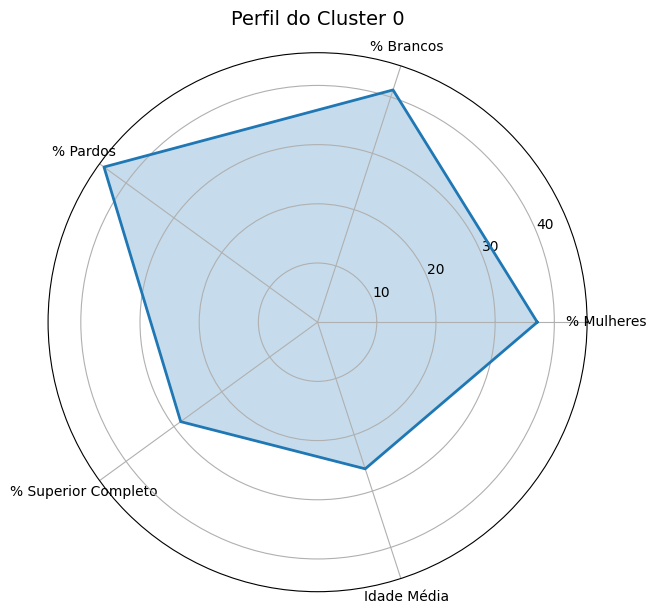

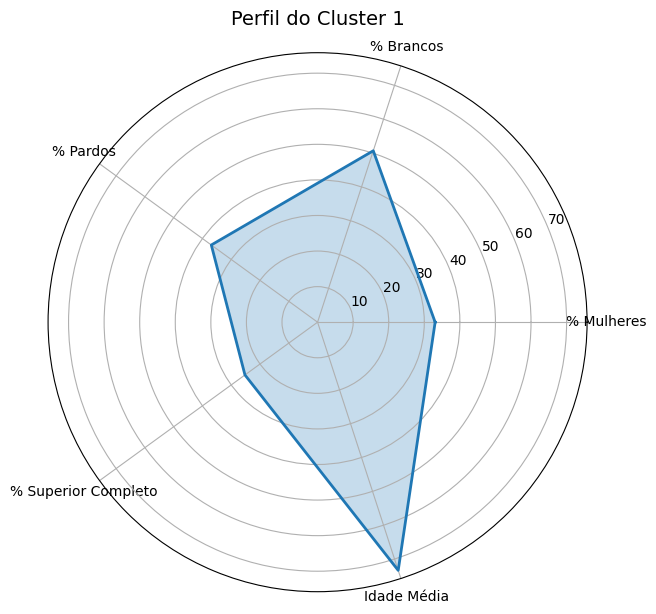

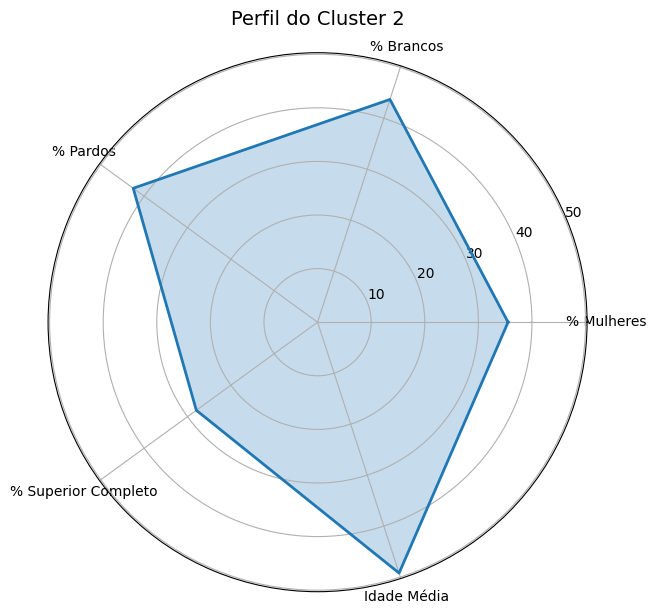

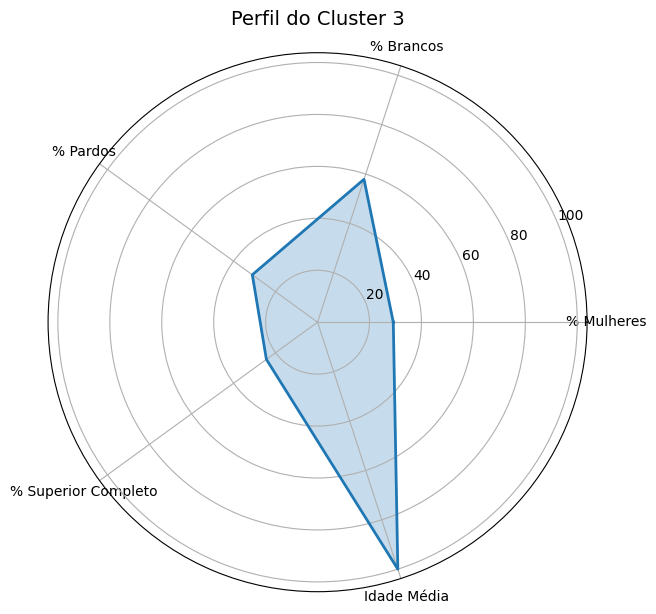

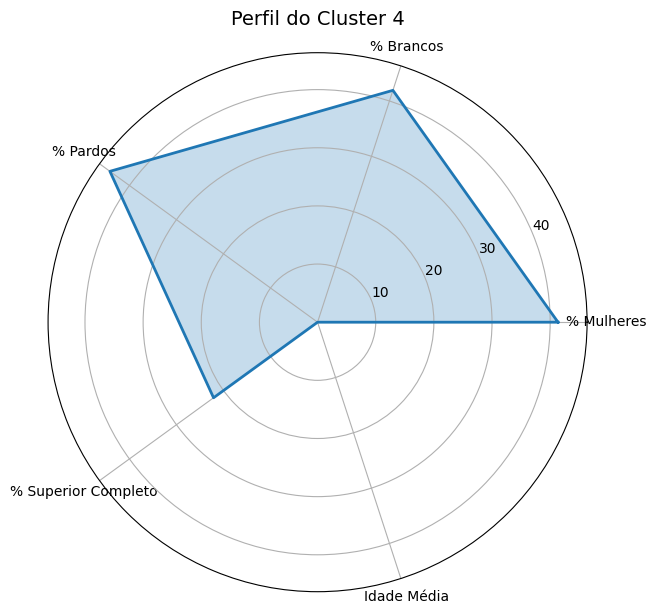

In [41]:
for cluster in radar_df['CLUSTER_KMEANS']:

    valores = radar_df[
        radar_df['CLUSTER_KMEANS'] == cluster
    ][variaveis].values.flatten().tolist()

    valores += valores[:1]

    fig, ax = plt.subplots(
        figsize=(7,7),
        subplot_kw=dict(polar=True)
    )

    ax.plot(angles, valores, linewidth=2)
    ax.fill(angles, valores, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    plt.title(
        f'Perfil do Cluster {cluster}',
        size=14,
        pad=20
    )

    plt.show()